# 01 - Data Understanding

## Objective
Develop a comprehensive understanding of the Employee Burnout & Attrition dataset, including its structure, variable types, distributions, and data quality characteristics. This foundational analysis will inform all subsequent exploration and modeling steps.

## Business Questions
1. What data do we have available to predict and understand employee attrition?
2. What is the overall structure and quality of the dataset?
3. How is the target variable (Attrition) distributed?
4. Which features are real (from IBM HR data) and which are synthetic/engineered?
5. Are there immediate data quality concerns that need attention?

---
## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the augmented dataset
DATA_PATH = Path('../data/processed/employee_attrition_augmented.csv')
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded successfully from: {DATA_PATH}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded successfully from: ..\data\processed\employee_attrition_augmented.csv
Shape: 1470 rows x 43 columns


---
## 2. Dataset Overview

### 2.1 First and Last Records
Examining the head and tail of the dataset to understand what a typical record looks like.

In [3]:
# First 5 records
print('=== First 5 Records ===')
df.head()

=== First 5 Records ===


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeID,EnvironmentSatisfaction,...,WeeklyHoursWorked,MonthlyMeetings,CompensationSatisfaction,CareerGrowthPerception,ManagerSupportScore,WorkModel,ProductivityScore,SalaryBand,ExperienceBand,TenureBand
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,55.9,9,3,1,4,Remote,5,Below Average,Mid (6-10),Veteran (6-10)
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,38.7,8,5,4,4,Onsite,4,Below Average,Mid (6-10),Veteran (6-10)
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,53.4,9,1,3,3,Remote,2,Low,Mid (6-10),New (0-1)
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,46.5,10,3,2,4,Onsite,3,Low,Mid (6-10),Veteran (6-10)
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,36.5,5,4,3,2,Onsite,3,Below Average,Mid (6-10),Settling (2-3)


In [4]:
# Last 5 records
print('=== Last 5 Records ===')
df.tail()

=== Last 5 Records ===


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeID,EnvironmentSatisfaction,...,WeeklyHoursWorked,MonthlyMeetings,CompensationSatisfaction,CareerGrowthPerception,ManagerSupportScore,WorkModel,ProductivityScore,SalaryBand,ExperienceBand,TenureBand
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,47.0,14,3,4,4,Onsite,5,Low,Senior (11-20),Established (4-5)
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,40.2,23,3,3,4,Hybrid,2,Average,Mid (6-10),Veteran (6-10)
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,48.8,15,4,4,4,Remote,4,Average,Mid (6-10),Veteran (6-10)
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,35.3,12,3,4,3,Onsite,3,Below Average,Senior (11-20),Veteran (6-10)
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,2068,2,...,38.7,11,4,4,3,Onsite,4,Below Average,Mid (6-10),Established (4-5)


### 2.2 Dataset Dimensions and Data Types

In [5]:
# Detailed info about the dataset
print('=== Dataset Info ===')
print(f'Number of records (employees): {df.shape[0]}')
print(f'Number of features: {df.shape[1]}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
df.info()

=== Dataset Info ===
Number of records (employees): 1470
Number of features: 43
Memory usage: 1363.8 KB

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1470 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   str    
 8   EmployeeID                1470 non-null   int64  
 9   EnvironmentSatisfaction   1470 non-null   int64  
 10  Gender                    1470 non-null   str    
 11  HourlyRate                1470 non-null   int64  
 12  JobInvolvement          

In [6]:
# Data types summary
print('=== Data Type Distribution ===')
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f'  {dtype}: {count} columns')
print(f'\nTotal: {df.shape[1]} columns')

=== Data Type Distribution ===
  int64: 30 columns
  str: 12 columns
  float64: 1 columns

Total: 43 columns


### 2.3 Statistical Summary

In [7]:
# Descriptive statistics for numerical columns
print('=== Numerical Features - Descriptive Statistics ===')
df.describe().T

=== Numerical Features - Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeID,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0


In [8]:
# Descriptive statistics for categorical columns
print('=== Categorical Features - Descriptive Statistics ===')
df.describe(include='object').T

=== Categorical Features - Descriptive Statistics ===


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
OverTime,1470,2,No,1054
WorkModel,1470,3,Onsite,647
SalaryBand,1470,5,Below Average,519


---
## 3. Column Categorization

We categorize columns by their origin and data type to better understand the dataset composition.

In [9]:
# Define column categories by origin
real_columns = [
    'Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
    'DistanceFromHome', 'Education', 'EducationField', 'EmployeeID',
    'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
    'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
    'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

synthetic_columns = [
    'WorkloadScore', 'WeeklyHoursWorked', 'MonthlyMeetings',
    'CompensationSatisfaction', 'CareerGrowthPerception',
    'ManagerSupportScore', 'WorkModel', 'ProductivityScore'
]

engineered_columns = ['SalaryBand', 'ExperienceBand', 'TenureBand']

print('=== Column Origin Classification ===')
print(f'Real (IBM HR Attrition):  {len(real_columns)} columns')
print(f'Synthetic (augmented):    {len(synthetic_columns)} columns')
print(f'Engineered (derived):     {len(engineered_columns)} columns')
print(f'Total accounted for:      {len(real_columns) + len(synthetic_columns) + len(engineered_columns)} columns')
print(f'Actual dataset columns:   {df.shape[1]} columns')

=== Column Origin Classification ===
Real (IBM HR Attrition):  32 columns
Synthetic (augmented):    8 columns
Engineered (derived):     3 columns
Total accounted for:      43 columns
Actual dataset columns:   43 columns


In [10]:
# Identify any columns not yet categorized
all_categorized = set(real_columns + synthetic_columns + engineered_columns)
actual_columns = set(df.columns)

uncategorized = actual_columns - all_categorized
missing_from_data = all_categorized - actual_columns

if uncategorized:
    print(f'Columns in dataset but not categorized: {uncategorized}')
if missing_from_data:
    print(f'Columns categorized but not in dataset: {missing_from_data}')
if not uncategorized and not missing_from_data:
    print('All columns are accounted for and categorized correctly.')

All columns are accounted for and categorized correctly.


In [11]:
# Categorize by data type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('=== Data Type Classification ===')
print(f'\nNumerical columns ({len(numerical_cols)}):')
for col in numerical_cols:
    print(f'  - {col} (range: {df[col].min()} to {df[col].max()})')

print(f'\nCategorical columns ({len(categorical_cols)}):')
for col in categorical_cols:
    print(f'  - {col} (unique values: {df[col].nunique()})')

=== Data Type Classification ===

Numerical columns (31):
  - Age (range: 18 to 60)
  - DailyRate (range: 102 to 1499)
  - DistanceFromHome (range: 1 to 29)
  - Education (range: 1 to 5)
  - EmployeeID (range: 1 to 2068)
  - EnvironmentSatisfaction (range: 1 to 4)
  - HourlyRate (range: 30 to 100)
  - JobInvolvement (range: 1 to 4)
  - JobLevel (range: 1 to 5)
  - JobSatisfaction (range: 1 to 4)
  - MonthlyIncome (range: 1009 to 19999)
  - MonthlyRate (range: 2094 to 26999)
  - NumCompaniesWorked (range: 0 to 9)
  - PercentSalaryHike (range: 11 to 25)
  - PerformanceRating (range: 3 to 4)
  - RelationshipSatisfaction (range: 1 to 4)
  - StockOptionLevel (range: 0 to 3)
  - TotalWorkingYears (range: 0 to 40)
  - TrainingTimesLastYear (range: 0 to 6)
  - WorkLifeBalance (range: 1 to 4)
  - YearsAtCompany (range: 0 to 40)
  - YearsInCurrentRole (range: 0 to 18)
  - YearsSinceLastPromotion (range: 0 to 15)
  - YearsWithCurrManager (range: 0 to 17)
  - WorkloadScore (range: 1 to 5)
  - Week

---
## 4. Data Quality Assessment

### 4.1 Missing Values

In [12]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('=== Missing Values Summary ===')
if missing.sum() == 0:
    print('No missing values found in the dataset.')
else:
    print(missing_summary[missing_summary['Missing Count'] > 0])

print(f'\nTotal missing values: {missing.sum()}')
print(f'Columns with missing values: {(missing > 0).sum()}')

=== Missing Values Summary ===
No missing values found in the dataset.

Total missing values: 0
Columns with missing values: 0


### 4.2 Duplicate Records

In [13]:
# Check for duplicate records
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['EmployeeID'].duplicated().sum() if 'EmployeeID' in df.columns else 'N/A'

print('=== Duplicate Records Check ===')
print(f'Fully duplicate rows: {duplicate_rows}')
print(f'Duplicate EmployeeIDs: {duplicate_ids}')

if duplicate_rows > 0:
    print('\nDuplicate rows detected - these should be investigated in the cleaning phase.')
else:
    print('\nNo duplicate records found. Each row represents a unique entry.')

=== Duplicate Records Check ===
Fully duplicate rows: 0
Duplicate EmployeeIDs: 0

No duplicate records found. Each row represents a unique entry.


### 4.3 Unique Value Counts

In [14]:
# Unique values per column
unique_counts = df.nunique().sort_values(ascending=False)

print('=== Unique Value Counts ===')
for col, count in unique_counts.items():
    pct = (count / len(df)) * 100
    indicator = '  <-- potential ID' if pct > 90 else ''
    print(f'  {col}: {count} unique values ({pct:.1f}%){indicator}')

=== Unique Value Counts ===
  EmployeeID: 1470 unique values (100.0%)  <-- potential ID
  MonthlyRate: 1427 unique values (97.1%)  <-- potential ID
  MonthlyIncome: 1349 unique values (91.8%)  <-- potential ID
  DailyRate: 886 unique values (60.3%)
  WeeklyHoursWorked: 253 unique values (17.2%)
  HourlyRate: 71 unique values (4.8%)
  Age: 43 unique values (2.9%)
  TotalWorkingYears: 40 unique values (2.7%)
  YearsAtCompany: 37 unique values (2.5%)
  MonthlyMeetings: 36 unique values (2.4%)
  DistanceFromHome: 29 unique values (2.0%)
  YearsInCurrentRole: 19 unique values (1.3%)
  YearsWithCurrManager: 18 unique values (1.2%)
  YearsSinceLastPromotion: 16 unique values (1.1%)
  PercentSalaryHike: 15 unique values (1.0%)
  NumCompaniesWorked: 10 unique values (0.7%)
  JobRole: 9 unique values (0.6%)
  TrainingTimesLastYear: 7 unique values (0.5%)
  EducationField: 6 unique values (0.4%)
  ExperienceBand: 5 unique values (0.3%)
  CareerGrowthPerception: 5 unique values (0.3%)
  ManagerSup

---
## 5. Target Variable Analysis

In [15]:
# Attrition distribution
print('=== Target Variable: Attrition ===')
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print(f'\nDistribution:')
for val in attrition_counts.index:
    print(f'  {val}: {attrition_counts[val]} employees ({attrition_pct[val]:.1f}%)')

print(f'\nImbalance ratio: {attrition_counts.max() / attrition_counts.min():.1f}:1')
print(f'Minority class (Yes): {attrition_pct.min():.1f}% of the dataset')

=== Target Variable: Attrition ===

Distribution:
  No: 1233 employees (83.9%)
  Yes: 237 employees (16.1%)

Imbalance ratio: 5.2:1
Minority class (Yes): 16.1% of the dataset


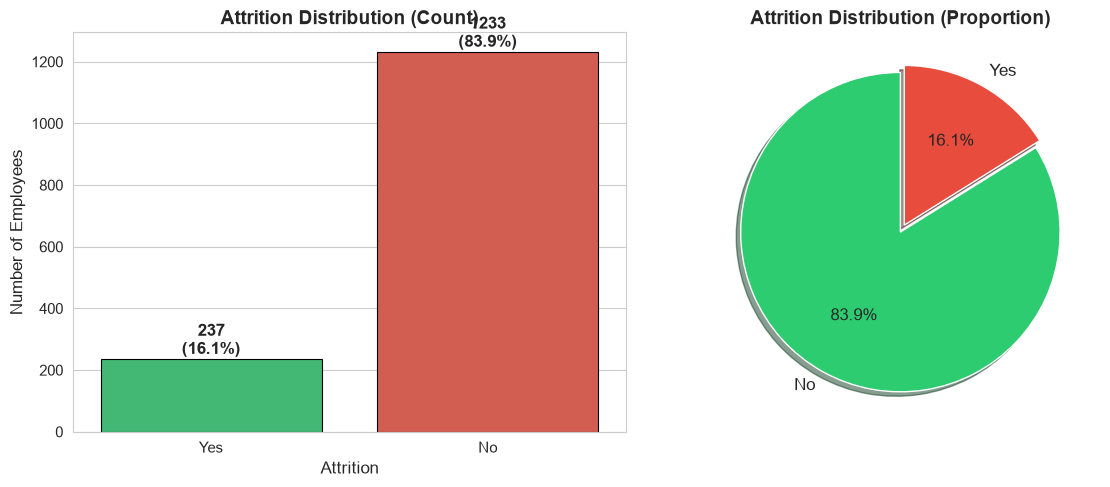

Note: The target variable is imbalanced. This will need to be addressed during modeling.


In [16]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
sns.countplot(data=df, x='Attrition', ax=axes[0], palette=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Attrition Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0, 0.05), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Attrition Distribution (Proportion)', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: The target variable is imbalanced. This will need to be addressed during modeling.')

**Interpretation:** The attrition rate is approximately 16.1%, meaning roughly 1 in 6 employees left the organization. This class imbalance is typical in real-world HR datasets and will require careful handling during model training (e.g., SMOTE, class weights, or stratified sampling).

---
## 6. Initial Observations and Feature Overview

In [17]:
# Quick look at ordinal/likert scale variables
likert_cols = ['EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction',
               'RelationshipSatisfaction', 'WorkLifeBalance', 'WorkloadScore',
               'CompensationSatisfaction', 'CareerGrowthPerception',
               'ManagerSupportScore', 'ProductivityScore']

print('=== Likert/Ordinal Scale Variables ===')
for col in likert_cols:
    if col in df.columns:
        vals = sorted(df[col].unique())
        print(f'  {col}: values {vals}, mean={df[col].mean():.2f}')

=== Likert/Ordinal Scale Variables ===
  EnvironmentSatisfaction: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4)], mean=2.72
  JobInvolvement: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4)], mean=2.73
  JobSatisfaction: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4)], mean=2.73
  RelationshipSatisfaction: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4)], mean=2.71
  WorkLifeBalance: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4)], mean=2.76
  WorkloadScore: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)], mean=3.46
  CompensationSatisfaction: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)], mean=3.40
  CareerGrowthPerception: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)], mean=3.33
  ManagerSupportScore: values [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)], mean=3.49
  ProductivityScore: values [np.int64(1), np.int64(2), np.int64(3

In [18]:
# Quick look at categorical variables value distributions
print('=== Categorical Variable Value Counts ===')
for col in categorical_cols:
    print(f'\n{col}:')
    for val, count in df[col].value_counts().items():
        print(f'  {val}: {count} ({count/len(df)*100:.1f}%)')

=== Categorical Variable Value Counts ===

Attrition:
  No: 1233 (83.9%)
  Yes: 237 (16.1%)

BusinessTravel:
  Travel_Rarely: 1043 (71.0%)
  Travel_Frequently: 277 (18.8%)
  Non-Travel: 150 (10.2%)

Department:
  Research & Development: 961 (65.4%)
  Sales: 446 (30.3%)
  Human Resources: 63 (4.3%)

EducationField:
  Life Sciences: 606 (41.2%)
  Medical: 464 (31.6%)
  Marketing: 159 (10.8%)
  Technical Degree: 132 (9.0%)
  Other: 82 (5.6%)
  Human Resources: 27 (1.8%)

Gender:
  Male: 882 (60.0%)
  Female: 588 (40.0%)

JobRole:
  Sales Executive: 326 (22.2%)
  Research Scientist: 292 (19.9%)
  Laboratory Technician: 259 (17.6%)
  Manufacturing Director: 145 (9.9%)
  Healthcare Representative: 131 (8.9%)
  Manager: 102 (6.9%)
  Sales Representative: 83 (5.6%)
  Research Director: 80 (5.4%)
  Human Resources: 52 (3.5%)

MaritalStatus:
  Married: 673 (45.8%)
  Single: 470 (32.0%)
  Divorced: 327 (22.2%)

OverTime:
  No: 1054 (71.7%)
  Yes: 416 (28.3%)

WorkModel:
  Onsite: 647 (44.0%)
  Hy

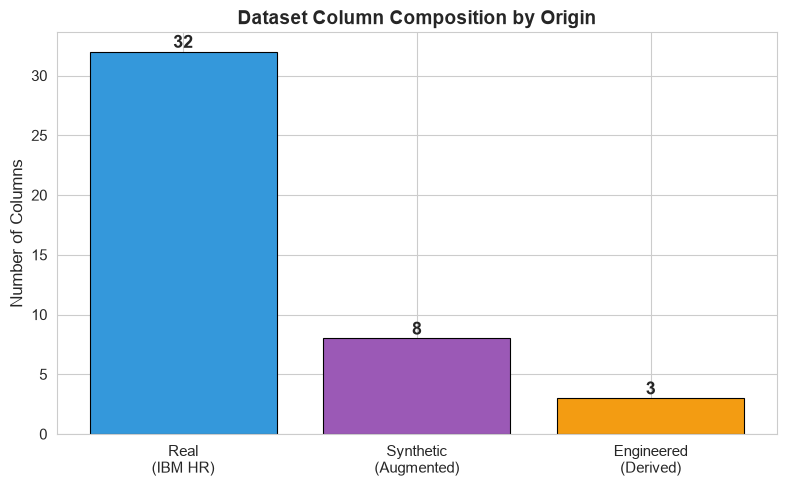

In [19]:
# Visualize column origin composition
fig, ax = plt.subplots(figsize=(8, 5))

origin_data = {
    'Real\n(IBM HR)': len([c for c in real_columns if c in df.columns]),
    'Synthetic\n(Augmented)': len([c for c in synthetic_columns if c in df.columns]),
    'Engineered\n(Derived)': len([c for c in engineered_columns if c in df.columns])
}

bars = ax.bar(origin_data.keys(), origin_data.values(),
              color=['#3498db', '#9b59b6', '#f39c12'], edgecolor='black', linewidth=0.8)
ax.set_title('Dataset Column Composition by Origin', fontweight='bold')
ax.set_ylabel('Number of Columns')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_column_composition.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Key Findings

### Dataset Structure
- The dataset contains **1,470 employee records** with **43 features** covering demographics, job characteristics, satisfaction metrics, and performance indicators.
- **32 columns** come from the original IBM HR Attrition dataset (real data), **8 columns** are synthetic augmentations, and **3 columns** are engineered features.

### Data Quality
- No missing values detected across any column.
- No duplicate records found.
- EmployeeID appears to uniquely identify each record.

### Target Variable
- **Attrition is imbalanced**: approximately 83.9% No vs 16.1% Yes.
- The imbalance ratio is roughly 5.2:1, which is significant but manageable with appropriate techniques.

### Feature Types
- Mix of continuous (income, hours, rates), ordinal (satisfaction scales 1-5), and categorical (department, role, work model) variables.
- Multiple Likert-scale variables (1-4 or 1-5) capture employee sentiment and perception.

---
## 8. Business Implications

1. **Rich feature set**: The combination of real and synthetic data provides a comprehensive view of factors that may drive attrition, from compensation to work-life balance to manager relationships.

2. **Class imbalance consideration**: With only 16.1% attrition, predictive models must be carefully evaluated. Accuracy alone will be misleading; we need to focus on precision, recall, and F1-score for the minority class.

3. **Actionable features**: Many features (OverTime, WorkModel, ManagerSupportScore) represent levers that organizations can actually pull to reduce attrition, making this dataset well-suited for prescriptive analytics.

4. **Data readiness**: The clean state of the data (no missing values, no duplicates) suggests it is well-prepared, though we should still validate ranges and distributions in the cleaning notebook.

---
*Next: Proceed to `02_data_cleaning.ipynb` for detailed data quality assessment and preparation.*